<b>Alkoholfogyasztással összefüggő közúti balesetek elemzése és előrejelzése Magyarországon hivatalos statisztikai adatok alapján</b>

A projekt célja az alkohollal összefüggő közúti balesetek alakulásának vizsgálata Magyarországon, a Központi Statisztikai Hivatal nyilvánosan elérhető adatainak* felhasználásával. Az elemzés az alábbi adatforrásokra épül: a személygépkocsi-állomány nagysága, az alkoholfüggők becsült száma, az összes közúti baleset, valamint az ittasan okozott balesetek száma.

1. Az elemzés első lépéseként feltáró adatelemzést végzünk, amelynek célja a főbb statisztikai jellemzők és időbeli trendek azonosítása. Leíró statisztikák, vizualizációk és korrelációs vizsgálatok segítségével elemezzük, hogyan függ össze a közúti forgalom és az alkoholfogyasztással kapcsolatos mutatók alakulása a baleseti adatokkal. Kiemelt célunk annak vizsgálata is, hogy a <b>2008-ban bevezetett zéró tolerancia szabályozás kimutatható javulást okozott-e</b> a trendekben, és hozzájárult-e az ittasan okozott balesetek számának csökkenéséhez.

2. Az eredmények alapján egy egyszerű prediktív modellt építünk, amely a rendelkezésre álló magyarázó változók segítségével becslést ad az alkohollal összefüggő balesetek alakulására.

3. Az elemzés végén az eredményeket közlekedésbiztonsági szempontból értelmezzük, különös tekintettel a szabályozási és társadalmi hatások szerepére.

*Adattáblák forrásai:<br>
Személysérüléses közúti közlekedési balesetek az okozók szerint: https://www.ksh.hu/stadat_files/ege/hu/ege0064.html <br>
A személygépkocsi-állomány gyártmány és üzemanyag-felhasználás szerint: https://www.ksh.hu/stadat_files/sza/hu/sza0025.html <br>
Ittasan okozott személysérüléses közúti közlekedési balesetek: https://www.ksh.hu/stadat_files/ege/hu/ege0066.html <br>
Az alkoholisták gondozása: https://www.ksh.hu/stadat_files/ege/hu/ege0030.html <br>
Alkohol okozta mentális és viselkedészavar miatt egészségügyi járóbeteg szakellátásban részesülők: https://www.ksh.hu/stadat_files/ege/hu/ege0085.html

<b>I. Adatok betöltése és tisztítása</b>

Az elemzés megkezdése előtt a választott KSH táblákat egységesíteni és tisztítani kell.
Az egyes táblák eltérő időszakokat fednek le, ezért csak azokat az éveket tartjuk meg, amelyek minden adatforrásban szerepelnek.

Az alkoholfüggőséggel kapcsolatos adatokat két külön forrás tartalmazza: az egyik a korábbi évekre, a másik a későbbi időszakra vonatkozó becsléseket ad meg, részben átfedéssel. Ezek egyesítésre kerülnek.
A növekvő gépjárműállomány hatásának kiszűrésére egy normalizált mutatót is létrehozunk (ittas balesetek száma 100 000 személygépkocsira vetítve).

Az előkészítési lépések után az adatok egyetlen, közös "dataframe"-be, azaz adattáblába kerülnek.

In [142]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root / "src"))

import importlib
import load_data
importlib.reload(load_data)

from load_data import load_road_accidents, load_intoxicated_accidents, load_personal_cars, load_alcohol_dependence, load_alcohol_treatment

intoxicated_accidents = load_intoxicated_accidents("../data/ittasan_okozott_szemelyseruleses_balesetek.csv")
personal_cars = load_personal_cars("../data/szemelygepjarmu_allomany.csv")
road_injuries = load_road_accidents("../data/szemelyseruleses_kozlekedesi_balesetek.csv")
dependence_estimate_prev = load_alcohol_dependence("../data/alkoholistak_gondozas.csv")
dependence_estimate_fresh = load_alcohol_treatment("../data/alkohol_szakellatas.csv")

import clean_data
importlib.reload(clean_data)

from clean_data import merge_alcohol_data, merge_all_data, normalize_accidents, describe_intoxicated_rate

alcohol = merge_alcohol_data(dependence_estimate_prev, dependence_estimate_fresh)
dataFrame = merge_all_data(intoxicated_accidents, road_injuries, personal_cars, alcohol)
dataFrame = normalize_accidents(dataFrame)
dataFrame = describe_intoxicated_rate(dataFrame)

<b>Exploratory Data Analysis (EDA)</b>


Idődiagramok


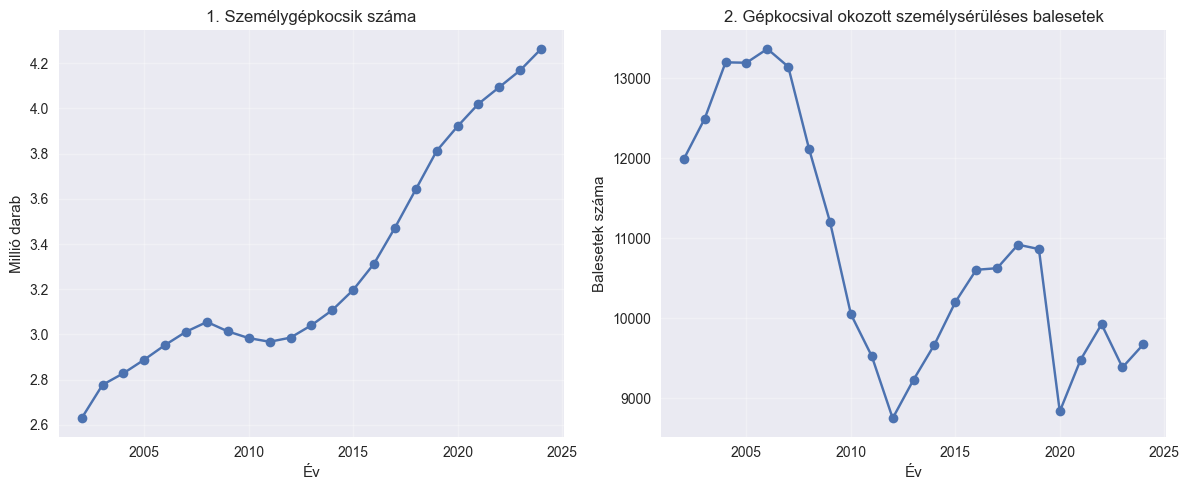

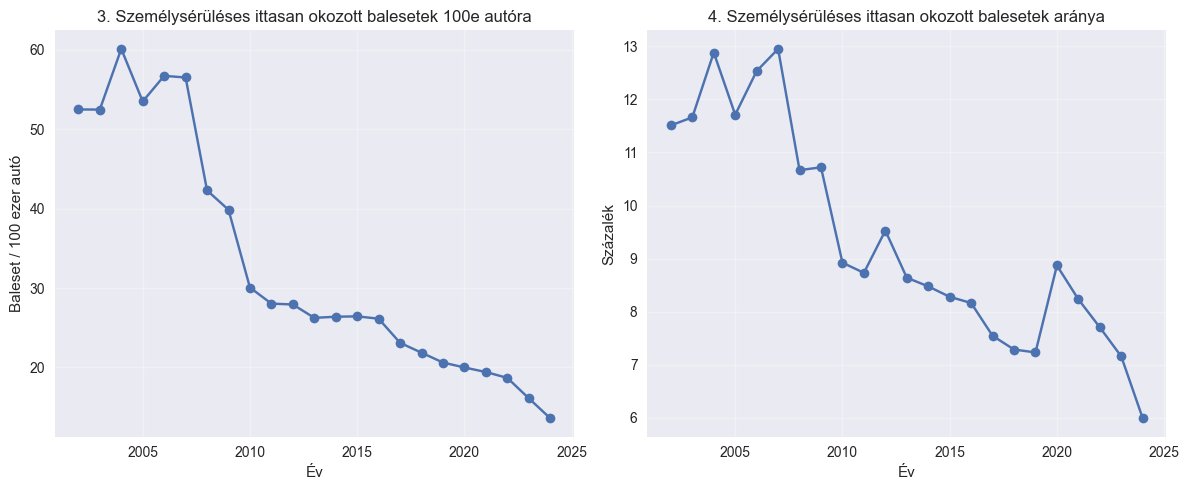

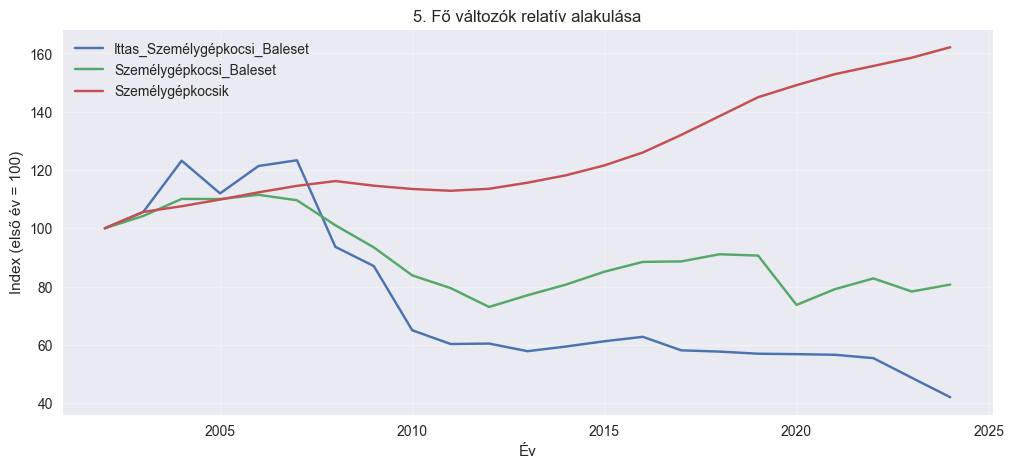

In [143]:
import eda
importlib.reload(eda)

from eda import plot_indexed_series, plot_double

print("\nIdődiagramok")

dataFrame["Személygépkocsik_Millió"] = dataFrame["Személygépkocsik"] / 1_000_000

plot_double(
    dataFrame=dataFrame,
    col1="Személygépkocsik_Millió",
    col2="Személygépkocsi_Baleset",
    title1="1. Személygépkocsik száma",
    title2="2. Gépkocsival okozott személysérüléses balesetek",
    ylabel1="Millió darab",
    ylabel2="Balesetek száma"
)

plot_double(
    dataFrame=dataFrame,
    col1="Ittas_Baleset_100ezer_Autóra",
    col2="Ittas_Baleset_Arány",
    title1="3. Személysérüléses ittasan okozott balesetek 100e autóra",
    title2="4. Személysérüléses ittasan okozott balesetek aránya",
    ylabel1="Baleset / 100 ezer autó",
    ylabel2="Százalék"
)

plot_indexed_series(
    dataFrame,
    [
        "Ittas_Személygépkocsi_Baleset",
        "Személygépkocsi_Baleset",
        "Személygépkocsik"
    ],
    "5. Fő változók relatív alakulása"
)

<b>Megállapítások:</b>

1-2. diagram (Személygépkocsik száma, Gépkocsival okozott személysérüléses balesetek): A személygépkocsik száma, azaz a fő kockázati referenciaszint folyamatosan és gyorsan növekedett a vizsgált időtartamon belül (≃2,6 millióról ≃4.2 millóra), a személysérüléses balesetek száma viszont csökkent. Ebből adódóan kijelenthető, hogy a személysérüléses balesetek száma nem azért csökkent, mert kevesebb eshetőség volt ezek bekövetkezésére az utakon.

2. diagram (Gépkocsival okozott személysérüléses balesetek): Az említett gépjárműállomány növekedés ellenére csökkent a személysérüléses balesetek mennyisége (≃12.000-ről ≃10.000-re). Ez minden bizonnyal nagyobb részben betudható olyan tényezőknek, mint például: balesetmegelőző technológia fejlődése az autóiparban, javuló kondíciók az infrastruktúrában (utak, jelzések, stb), változó szabályozási környezet
   
3. diagram (Személysérüléses ittasan okozott balesetek 100e autóra): Amennyiben "nyers" számokat vizsgálnánk, a balesetek, vagy aktív autók számának drasztikus változása torzítana az elemzésen, ezért lett létrehozva a '100 ezer autóra normalizált ittas gépjárművezetők által okozott személysérüléses balesetek' értéksor. Ennek segítségével megállapíthatjuk, hogy a vizsgált probléma, azaz az ittasan elkövetett személyi kár okozása ténylegesen csökkenőben van az autósok populációjához viszonyítva.

4. diagram (Személysérüléses ittasan okozott balesetek aránya): A személysérüléses balesetek természetét vizsgálva azt látjuk, hogy az előforduló balesetek számán belül folyamatosan csökken az ittas elkövetők aránya (≃11%-ról ≃6%-ra). Ez arra enged következtetni, hogy az emberek viselkedése, vezetési kultúrája változott a vizsgált tartamon belül.

---


Korrelációk vizsgálata


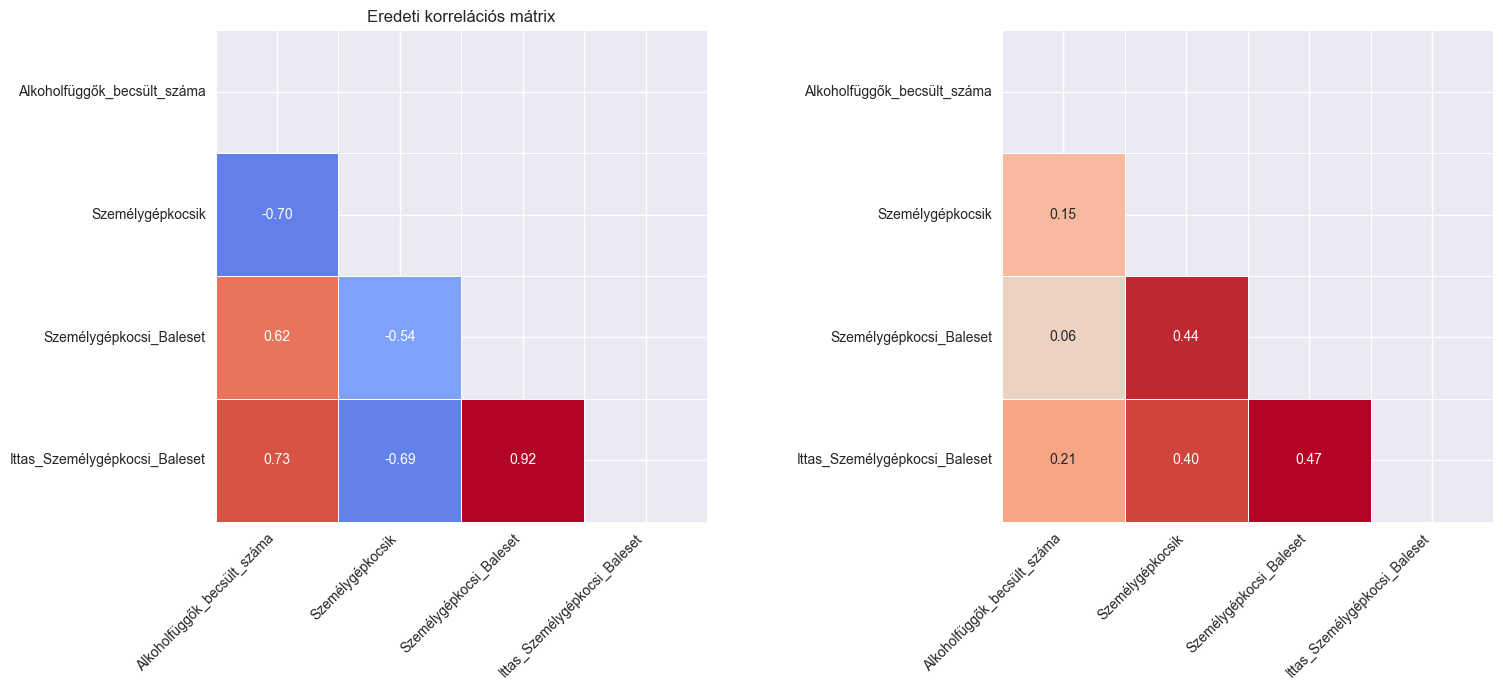

In [136]:
from eda import plot_dual_correlation_matrix, plot_comparative_scatters

print("\nKorrelációk vizsgálata")

plot_dual_correlation_matrix(dataFrame, [
    "Alkoholfüggők_becsült_száma",
    "Személygépkocsik",
    "Személygépkocsi_Baleset",
    "Ittas_Személygépkocsi_Baleset",
], [ "Eredeti korrelációs mátrix", "Trendmentesített mátrix (YoY % változás)"])

<b>Megállapítások:<b>

1. mátrix (Eredeti korrelációs mátrix): Ez a "szimpla" mátrix egy klasszikus csapdába vezet minket. 20+ éves időtartamra nézve vizsgál értékeket, igen erős korrelációkat mutat pozitív és negatív irányba is (pl. -0.70 korreláció autók száma és ittasan elkövetett személysérüléses balesetek között). Mivel minden változó azonos idővonalon belül változik, könnyen hamis következtetéseket vonhatnánk le belőle, mint: "az autók számának növekedése erős összefüggésben van az ittasan elkövetett balesetek számának csökkenésével. Pedig tulajdonképpen a változó értékének okozója az, hogy mindkét mennyiségbeli változás ugyanabban a két évtizedben következett be.
2. mátrix (Trendmentesített korrelációs mátrix): A mátrixot trendmentesítve vizsgálható, hogy amennyiben egyik évről a másikra változik valamely vizsgált mennyiség, melyik változók csökkennek vele együtt. A kapott eredményről leolvashatjuk, hogy a korrelációs értékek így jelentősen csökkennek. 

    - Összes baleset vs. Ittas balesetek (0.92-ről 0.47-re csökkent): Bár még mindig ez a legerősebb kapcsolatunk, a 0.47 egyáltalán nem tökéletes egyezés. Ez azt jelenti, hogy ha egy adott évben rosszabbak az útviszonyok (pl. kemény tél), akkor az összes balesettel együtt az ittas balesetek száma is megnőhet. Ugyanakkor az alacsonyabb korreláció bizonyítja, hogy az ittas vezetésnek megvan a maga különálló dinamikája.

    - Alkoholfüggők becsült száma vs. Ittas balesetek (0.73-ról 0.21-re csökkent): A nyers adatok alapján szorosnak tűnt a kapcsolat, de a trendmentesítés rávilágított arra, hogy ha egy adott évben hirtelen megnő az alkoholfüggők száma, az nem okoz azonnali kiugrást az ittas balesetek számában. (mivel sajnos csak becsült érték áll rendelkezésre a függő személyek számáról, ez valamelyest megkérdőjelezhető)

---


Szórás / pontdiagram


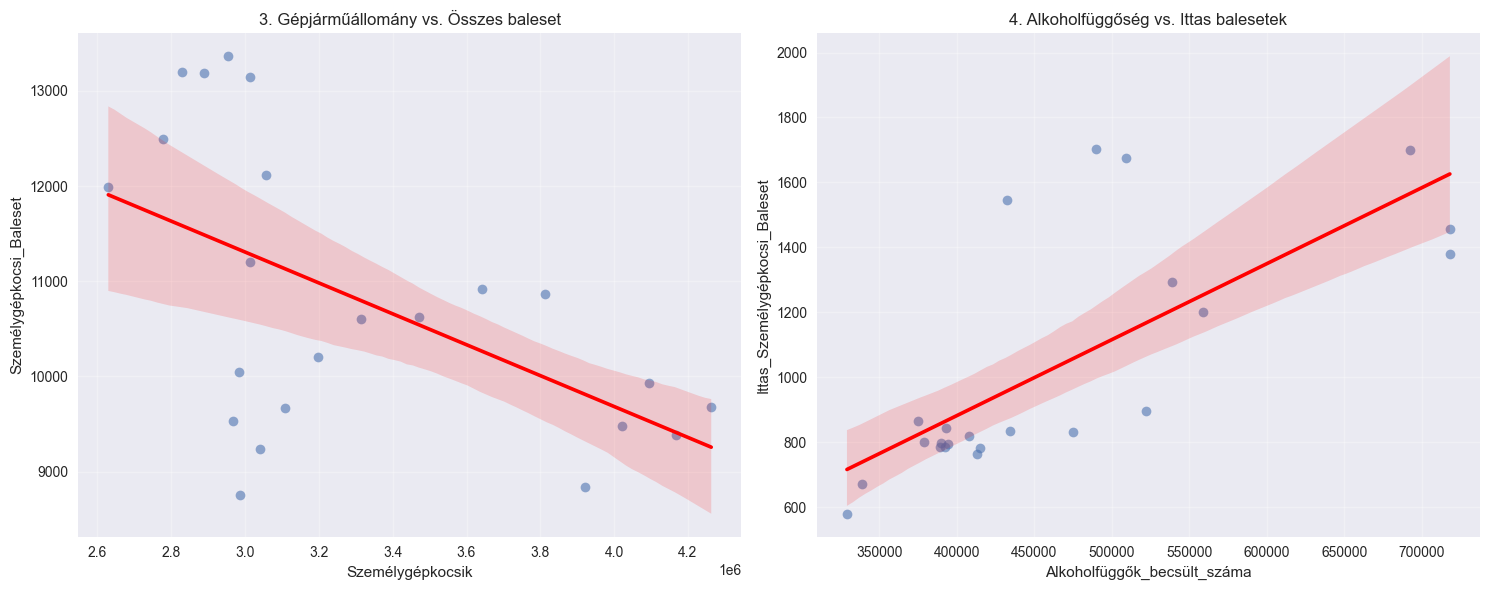

In [137]:
print("\nSzórás / pontdiagram")
plot_comparative_scatters(
    dataFrame, 
    x_variables=["Személygépkocsik", "Alkoholfüggők_becsült_száma"],
    y_variables=["Személygépkocsi_Baleset", "Ittas_Személygépkocsi_Baleset"],
    titles=["3. Gépjárműállomány vs. Összes baleset", "4. Alkoholfüggőség vs. Ittas balesetek"]
)

<b>Megállapítások:</b>

1. pontdiagram (Gépjárműállomány vs. Összes baleset):
Látszólag minél több az autó, annál kevesebb a baleset. Ez azonban csak látszólagos korreláció. Nem a több autó véd meg a balesetektől, hanem az idő múlását látjuk: az elmúlt 20 évben nőtt az autók száma, de közben a járművek és az infrastruktúra is sokkal biztonságosabbá váltak.

2. pontdiagram (Alkoholfüggőség vs. Ittas balesetek):
A trendvonal emelkedik (több függő = több baleset), de a lényeg az adatok szórása. Alacsonyabb számoknál a pontok sűrűek, így a kapcsolat egyértelmű. A kiugróan magas értékeknél (500 ezer felett) viszont már hatalmas a szórás, ami azt mutatja, hogy az extrém éveket ebből a változóból nehéz megbízhatóan előrejelezni.

---


 Potenciális töréspontok


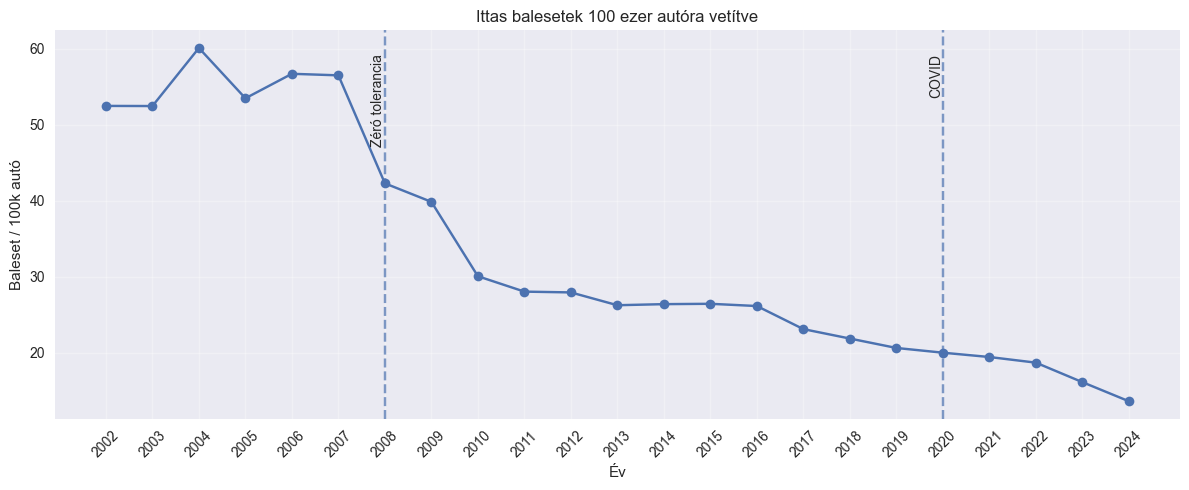

In [138]:
print("\n Potenciális töréspontok")

from eda import plot_time_series, plot_scatter

plot_time_series(
    dataFrame,
    "Ittas_Baleset_100ezer_Autóra",
    "Ittas balesetek 100 ezer autóra vetítve",
    "Baleset / 100k autó",
    breakpoints=[
        (2008, "Zéró tolerancia"),
        (2020, "COVID")
    ]
)

<b>Megállapítások:</b>

1.Zéró tolerancia bevezetése (2008): A törvény bevezetése után a mutató csökkent 56-ról 42-re. Ebből a zuhanásból arra lehet következtetni, hogy a szigorú, azonnali büntetés azonnali és radikális viselkedésváltozást hozott a sofőröknél.

2-COVID-19 (2020): A járvány alatti lezárások nem okoztak kiugró változást, a grafikonon jól látszik, hogy az egyenletes, hosszú távú csökkenő trend a 2008-as sokk óta stabilan tartja magát.

----


Pontdiagramok időeltolás vizsgálatára


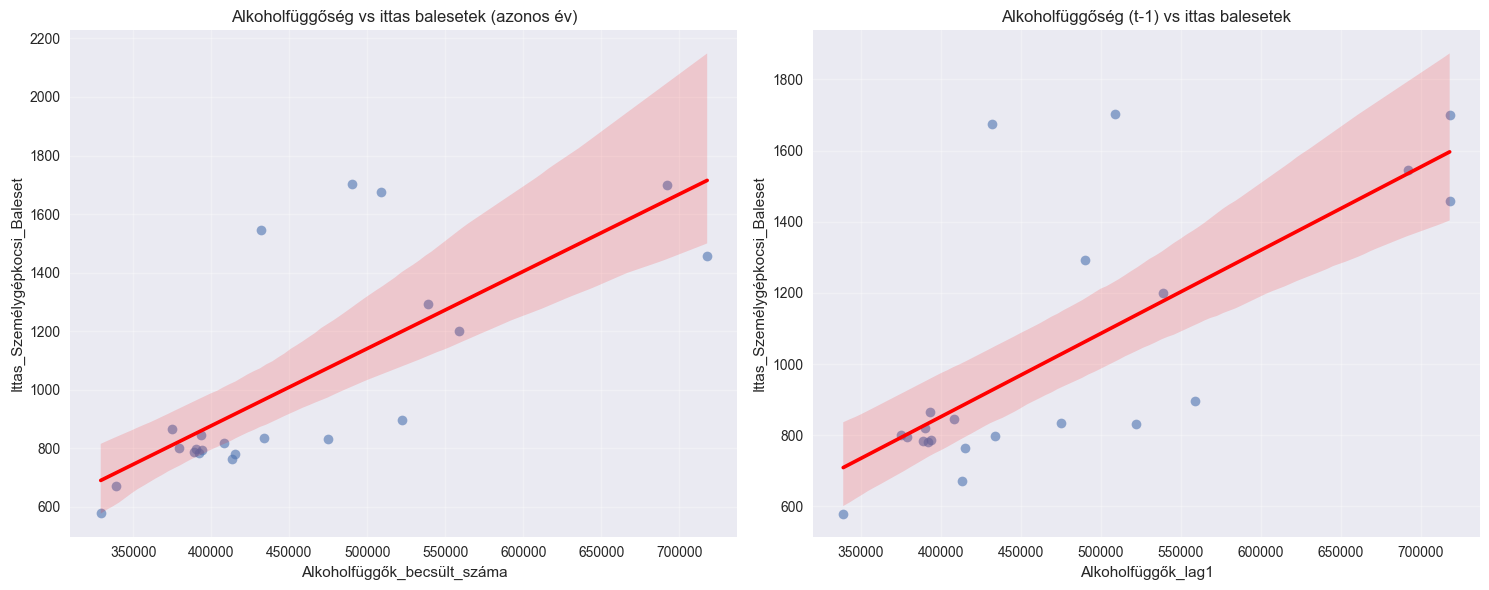

Adott évi korreláció: 0.7384448223421316, Korreláció 1 év időeltolással: 0.7231345784177443


In [139]:
print("\nPontdiagramok időeltolás vizsgálatára")

df_lag = dataFrame.copy()
df_lag["Alkoholfüggők_lag1"] = df_lag["Alkoholfüggők_becsült_száma"].shift(1)
df_lag = df_lag.dropna()

plot_comparative_scatters(
    df_lag,
    x_variables=[
        "Alkoholfüggők_becsült_száma",
        "Alkoholfüggők_lag1"
    ],
    y_variables=[
        "Ittas_Személygépkocsi_Baleset",
        "Ittas_Személygépkocsi_Baleset"
    ],
    titles=[
        "Alkoholfüggőség vs ittas balesetek (azonos év)",
        "Alkoholfüggőség (t-1) vs ittas balesetek"
    ]
)

val1 = df_lag["Alkoholfüggők_becsült_száma"].corr(df_lag["Ittas_Személygépkocsi_Baleset"])
val2 = df_lag["Alkoholfüggők_lag1"].corr(df_lag["Ittas_Személygépkocsi_Baleset"])

print(f"Adott évi korreláció: {val1}, Korreláció 1 év időeltolással: {val2}")

<b> Megállapítások:</b>

Ez a dupla pontdiagram az alkoholfüggők becsült száma és az ittas balesetek közötti viszonyt ábrázolja egy-egy trendvonallal, bal oldalon az azonos évi, jobb oldalon pedig az egy évvel korábbi adatok alapján.
Az eredmény: A két korrelációs érték gyakorlatilag megegyezik (0.738 azonos évben, és 0.723 egy év csúszással). A két grafikonon a pontok szórása is láthatóan nagyon hasonló.

A konklúzió: Leteszteltük azt a hipotézist, hogy az alkoholfüggőség, mint hosszabb távú folyamat jobban előrejelzi-e a következő év baleseteit. Az adatok ezt megcáfolták: az 1 éves időeltolás (t-1) nem hozott szorosabb kapcsolatot, nem javítja a modellünk pontosságát. A tavalyi függőségi adatokból nem tudjuk pontosabban megjósolni az idei baleseteket, mint az idei adatokból (sajnos ismételten igaz, hogy az adatok becsült természete sokat ront eredményeink hitelességén).

---

<b> Prediktív Modell </b>

Tengelymetszet: 68.731
R² Eredmény: 0.963

Együtthatók:
              Változó  Együttható
0               Trend   -1.504629
1  Alkoholfüggők_lag1   -0.000014
2     Zéró_Tolerancia  -16.705444


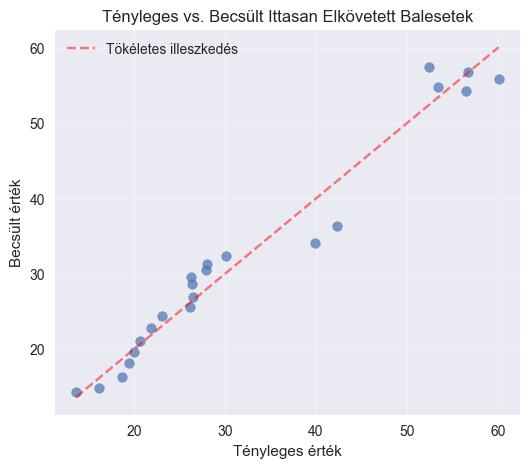

In [140]:
import importlib
import predictive_model
importlib.reload(predictive_model)

from predictive_model import prepare_model_data, forecast_model, compare_models, print_model_summary, plot_prediction_accuracy, showcase_model_results

model_df = prepare_model_data(dataFrame)

model, predictors, actual_accidents, predicted_accidents, r2 = forecast_model(
    model_df,
    "Ittas_Baleset_100ezer_Autóra",
    [
        "Trend",
        "Alkoholfüggők_lag1",
        "Zéró_Tolerancia"
    ]
)

showcase_model_results(model, predictors, actual_accidents, predicted_accidents, r2, "Tényleges vs. Becsült Ittasan Elkövetett Balesetek")

<b>Eredmények magyarázata</b>
1. Tengelymetszet: Mivel a trend az időt méri, a 68-as tengelymetszet szám a vizsgált időszak elején tapasztalható baleseti szintet tükrözi.
   
2. Determinációs együttható: a 96 magas érték, ami azt mutatja, hogy a modellünk szorosan illeszkedik a múltbeli adatsorhoz. Fontos azonban megjegyezni, hogy a Trend változó egy összefoglaló mutató: ez tartalmazza az összes olyan időbeli tényezőt (pl. technológiai fejlődés, útviszonyok), amelyet nem mértünk. A 96,3% tehát azt jelenti, hogy a választott változók és az időbeli trend együttesen közel teljes mértékben leírják a baleseti statisztika ingadozását, de valószínűsíthető, hogy a trend mögött nem azonosított külső hatások is állnak.

   
3. Együtthatók:

Trend (-1,505): Minden egyes eltelt évvel az ittas balesetek száma (100 ezer autóra vetítve) átlagosan 1,5-tel csökken.

Zéró_Tolerancia (-16,705): Mivel ez egy „flag" (0 a törvény előtt, 1 utána), az érték a jogszabály közvetlen hatását mutatja. A törvény bevezetése önmagában kimutathatóan csökkentette a 100 ezer autóra vetített ittas balesetek számát.

Alkoholfüggők_lag1 (-0.000014): Ez a szám gyakorlatilag nulla. Azt mutatja, hogy az országos alkoholfüggőségi statisztika éves szinten alig van hatással a balesetek számára.

---

In [141]:
model_specs = {
    "Csak Trend": ["Trend"],
    "Trend + Zéró Tolerancia": ["Trend", "Zéró_Tolerancia"],
    "Trend + Zéró Tolerancia + Függőség": ["Trend", "Zéró_Tolerancia", "Alkoholfüggők_lag1"]
}

comparison = compare_models(
    model_df,
    "Ittas_Baleset_100ezer_Autóra",
    model_specs
)

display(comparison)

,Model,R2,Trend,Zéró_Tolerancia,Alkoholfüggők_lag1
0,Csak Trend,0.859,-2.1118,,
1,Trend + Zéró Tolerancia,0.960,-1.3473,-15.9285,
2,Trend + Zéró Tolerancia + Függőség,0.963,-1.5046,-16.7054,-0.0


<b> Konklúziók </b>

1. Zéró tolerancia azonnali hatása (törvényi szabályozás ereje)

A prediktív modellünk egyértelműen bizonyítja a 2008-as jogszabály-szigorítás sikerét.
A törvény bevonása a modellbe 85.9%-ról 96%-ra növelte az előrejelzés pontosságát ($R^2$). A -15.9-es együttható azt jelenti, hogy a zéró tolerancia bevezetése önmagában, azonnali majdnem 16-tal csökkentette az ittas balesetek számát 100 ezer autóra vetítve.

3. Általános közlekedésbiztonsági javulás (a trend szerepe)

A jogszabályi 'sokk' mellett a modellünk kimutatta az idő múlásának folyamatos, pozitív hatását is. A járművek és az infrastruktúra fejlődésével és a vezetési kultúra javulásával a balesetek aránya alapjáraton is stabilan csökken (évente átlagosan -1.5-ös együtthatóval a törvény bevezetése utáni időszakban is).

5. Az egészségügyi becslések korlátozott alkalmassága a predikcióra (pontatlan adatok)

Bár az alkoholfüggőségi statisztikák és a balesetszámok között látható korreláció, a prediktív modellben ez a változó nem hozott többlet-pontosságot a trendhez és a jogszabályi változókhoz képest. Ez utalhat az egészségügyi adatok pontatlanságára, vagy arra, hogy a függőségi ráta változása lassabb folyamat, mint amit egy éves alapú közlekedési modell kezelni tud.